# Color 02 - Perception and rainbow pitfalls (Solution)

Muc tieu: nhan dien anti-pattern cua rainbow scale.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def resolve_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / "data" / "gapminder.csv").exists():
            return p
    raise FileNotFoundError("Cannot locate data/gapminder.csv")

root = resolve_repo_root()
sns.set_theme(style="white")
df = pd.read_csv(root / "data" / "gapminder.csv")
pivot = df.pivot_table(index="continent", columns="year", values="lifeExp", aggfunc="mean")
pivot

year,1952,1957,1962,1967,1972,1977,1982,1987,1992,1997,2002,2007
continent,,,,,,,,,,,,
Africa,39.135500,41.266346,43.319442,45.334538,47.450942,49.580423,51.592865,53.344788,53.629577,53.598269,53.325231,54.806038
Americas,53.279840,55.960280,58.398760,60.410920,62.394920,64.391560,66.228840,68.090720,69.568360,71.150480,72.422040,73.608120
Asia,46.314394,49.318544,51.563223,54.663640,57.319269,59.610556,62.617939,64.851182,66.537212,68.020515,69.233879,70.728485
Europe,64.408500,66.703067,68.539233,69.737600,70.775033,71.937767,72.806400,73.642167,74.440100,75.505167,76.700600,77.648600
Oceania,69.255000,70.295000,71.085000,71.310000,71.910000,72.855000,74.290000,75.320000,76.945000,78.190000,79.740000,80.719500


## 1) So sanh cung du lieu: rainbow vs perceptual sequential

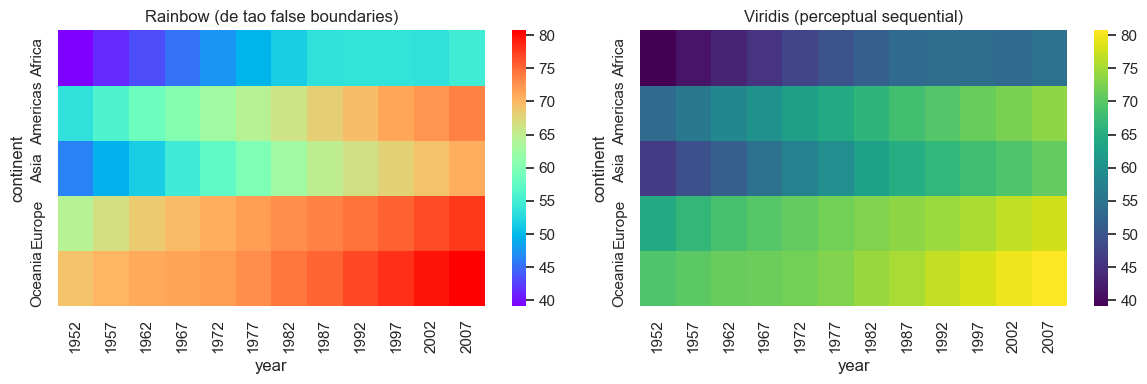

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.heatmap(pivot, cmap="rainbow", ax=axes[0])
axes[0].set_title("Rainbow (de tao false boundaries)")
sns.heatmap(pivot, cmap="viridis", ax=axes[1])
axes[1].set_title("Viridis (perceptual sequential)")
plt.tight_layout(); plt.show()

## 2) So sanh diverging dung cach khi co center

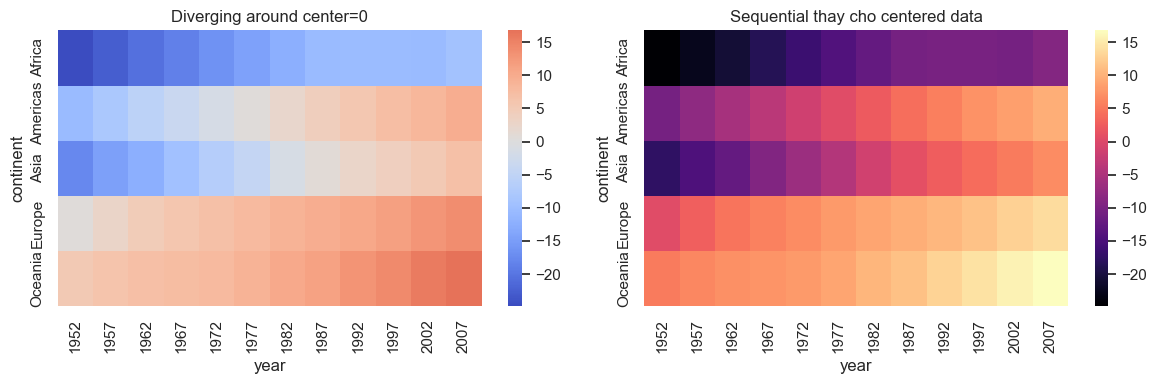

In [3]:
centered = pivot - pivot.to_numpy().mean()
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.heatmap(centered, cmap="coolwarm", center=0, ax=axes[0])
axes[0].set_title("Diverging around center=0")
sns.heatmap(centered, cmap="magma", ax=axes[1])
axes[1].set_title("Sequential thay cho centered data")
plt.tight_layout(); plt.show()

## 3) Hue vs luminance

Magnitude nen uu tien luminance monotonic de doc chinh xac hon.

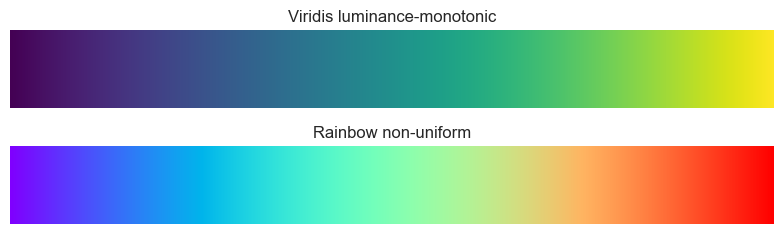

In [4]:
x = np.linspace(0, 1, 256)
grad = np.tile(x, (20, 1))
fig, axes = plt.subplots(2, 1, figsize=(8,2.5))
axes[0].imshow(grad, aspect="auto", cmap="viridis"); axes[0].set_title("Viridis luminance-monotonic")
axes[1].imshow(grad, aspect="auto", cmap="rainbow"); axes[1].set_title("Rainbow non-uniform")
for a in axes: a.set_axis_off()
plt.tight_layout(); plt.show()

## Reflection
- Neu stakeholder doi "mau cau vong cho dep", ban giai thich ra sao bang ngon ngu de hieu?